# Teaching Kernel SVM: Comparing Linear, Polynomial and RBF Kernels

This tutorial explains how different Support Vector Machine kernels affect classification performance and decision boundaries.

## Import Libraries

This cell imports the Python libraries needed for data handling, model building, evaluation and visualisation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.datasets import make_moons

RANDOM_STATE = 42
plt.rcParams['figure.figsize'] = (8, 5)

## Load and Inspect the Seeds Dataset

This cell loads the Seeds dataset and checks its shape, class balance and basic structure before modelling.

In [2]:
columns = [
    'Area',
    'Perimeter',
    'Compactness',
    'Kernel Length',
    'Kernel Width',
    'Asymmetry Coefficient',
    'Kernel Groove Length',
    'Class'
]

data = pd.read_csv('seeds_dataset.txt', sep=r'\s+', header=None)
data.columns = columns

print('Dataset shape:', data.shape)
print('\nMissing values:')
print(data.isnull().sum())
print('\nClass distribution:')
print(data['Class'].value_counts().sort_index())
display(data.head())

Dataset shape: (210, 8)

Missing values:
Area                     0
Perimeter                0
Compactness              0
Kernel Length            0
Kernel Width             0
Asymmetry Coefficient    0
Kernel Groove Length     0
Class                    0
dtype: int64

Class distribution:
Class
1    70
2    70
3    70
Name: count, dtype: int64


,Area,Perimeter,Compactness,Kernel Length,Kernel Width,Asymmetry Coefficient,Kernel Groove Length,Class
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


## Prepare the Training and Test Data

This cell separates the features and target variable, then creates training and test sets for fair evaluation.

In [4]:
X = data.drop(columns='Class')
y = data['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE
)

print('Training set shape:', X_train.shape)
print('Test set shape:', X_test.shape)

Training set shape: (157, 7)
Test set shape: (53, 7)


## Build, Tune and Fit the SVM Model

This cell creates an SVM pipeline with feature scaling, defines the hyperparameter search space, and uses GridSearchCV to identify the best kernel and model settings.

In [16]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC())
])

param_grid = [
    {
        'svc__kernel': ['linear'],
        'svc__C': [0.1, 1, 10, 100]
    },
    {
        'svc__kernel': ['poly'],
        'svc__C': [0.1, 1, 10],
        'svc__degree': [2, 3],
        'svc__gamma': ['scale', 'auto']
    },
    {
        'svc__kernel': ['rbf'],
        'svc__C': [0.1, 1, 10, 100],
        'svc__gamma': ['scale', 'auto', 0.1, 1]
    }
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=1,
    refit=True
)

grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_

print("Best tuned model: Support Vector Machine")
print("Best kernel:", best_params['svc__kernel'])
print("Best C value:", best_params['svc__C'])

if 'svc__degree' in best_params:
    print("Best degree:", best_params['svc__degree'])

if 'svc__gamma' in best_params:
    print("Best gamma:", best_params['svc__gamma'])

print("Best cross-validation accuracy:", round(grid_search.best_score_, 4))

Best tuned model: Support Vector Machine
Best kernel: linear
Best C value: 100
Best cross-validation accuracy: 0.9681


## Evaluate the Best Model

This cell evaluates the best tuned SVM on the unseen test set using accuracy and a classification report.

In [6]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)

print('Test accuracy:', round(test_accuracy, 4))
print('\nClassification report:')
print(classification_report(y_test, y_pred))

Test accuracy: 0.9057

Classification report:
              precision    recall  f1-score   support

           1       0.80      0.94      0.86        17
           2       0.94      0.83      0.88        18
           3       1.00      0.94      0.97        18

    accuracy                           0.91        53
   macro avg       0.91      0.91      0.91        53
weighted avg       0.91      0.91      0.91        53



## Plot the Confusion Matrix

This cell visualises how well the best model predicts each class.

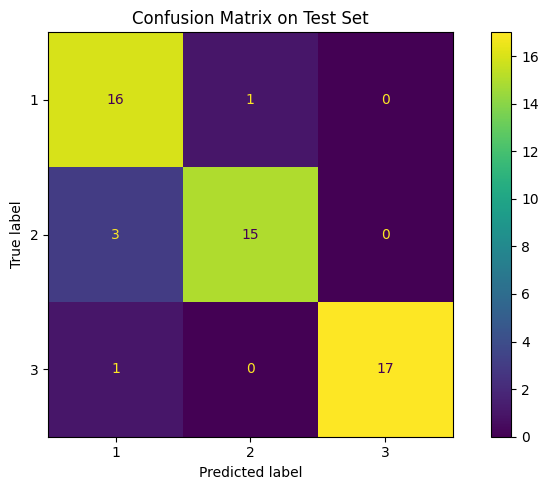

In [7]:
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
plt.title('Confusion Matrix on Test Set')
plt.tight_layout()
plt.show()

## Compare Linear, Polynomial and RBF Kernels

This cell compares the three main SVM kernels on the Seeds dataset to show how kernel choice affects performance.

In [9]:
kernel_models = {
    'Linear SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(kernel='linear', C=1.0))
    ]),
    'Polynomial SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(kernel='poly', degree=3, C=1.0, gamma='scale'))
    ]),
    'RBF SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(kernel='rbf', C=1.0, gamma='scale'))
    ])
}

results = []

for name, model in kernel_models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    results.append({'Model': name, 'Test Accuracy': acc})

results_df = pd.DataFrame(results).sort_values(by='Test Accuracy', ascending=False)
display(results_df)

,Model,Test Accuracy
0,Linear SVM,0.886792
2,RBF SVM,0.886792
1,Polynomial SVM,0.867925


## Visualise Kernel Performance

This cell presents the kernel comparison results in a simple bar chart.

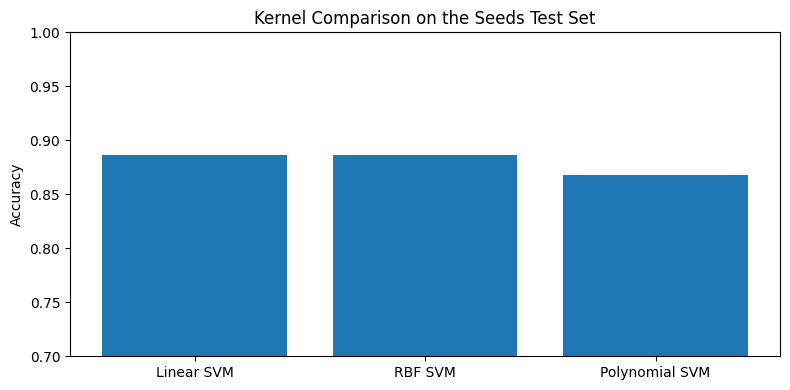

In [10]:
plt.figure(figsize=(8, 4))
plt.bar(results_df['Model'], results_df['Test Accuracy'])
plt.ylim(0.7, 1.0)
plt.ylabel('Accuracy')
plt.title('Kernel Comparison on the Seeds Test Set')
plt.tight_layout()
plt.show()

## Create a Synthetic Dataset and Plot Function

This cell creates a non-linear moons dataset and defines a reusable function for plotting decision boundaries.

In [11]:
X_moons, y_moons = make_moons(n_samples=300, noise=0.2, random_state=RANDOM_STATE)

def plot_decision_boundary(ax, model, X, y, title):
    model.fit(X, y)

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    ax.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor='k', cmap='viridis')
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

## Compare Kernel Decision Boundaries

This cell shows how linear, polynomial and RBF kernels produce different boundaries on non-linear data.

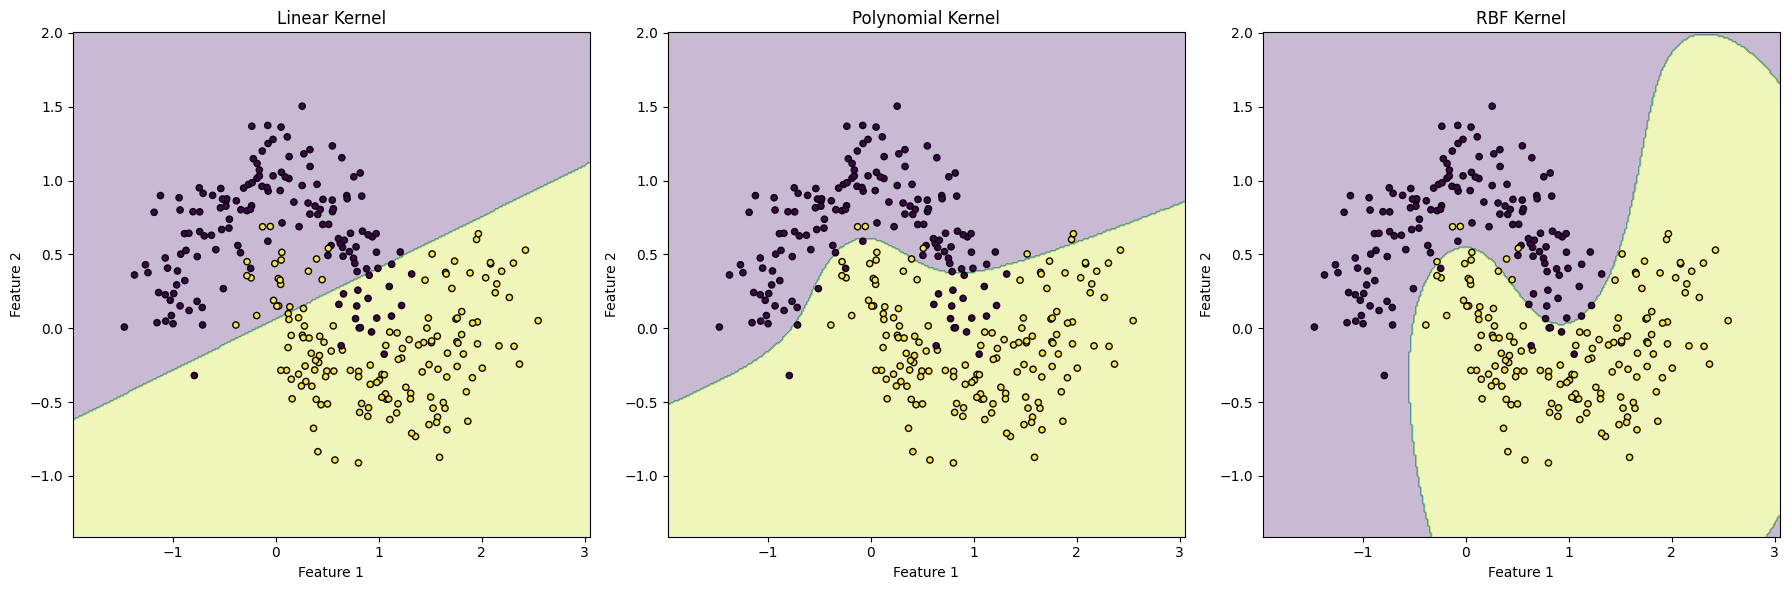

In [12]:
moon_models = [
    ('Linear Kernel', SVC(kernel='linear', C=1.0)),
    ('Polynomial Kernel', SVC(kernel='poly', degree=3, C=1.0, gamma='scale')),
    ('RBF Kernel', SVC(kernel='rbf', C=1.0, gamma='scale'))
]


fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (name, model) in zip(axes, moon_models):
    plot_decision_boundary(ax, model, X_moons, y_moons, name)

plt.tight_layout()

plt.savefig("Moons_Kernel_Comparison.png", dpi=300, bbox_inches='tight')
plt.show()

## Show the Effect of C and Gamma

This cell demonstrates how the RBF kernel changes when the hyperparameters C and gamma are adjusted.

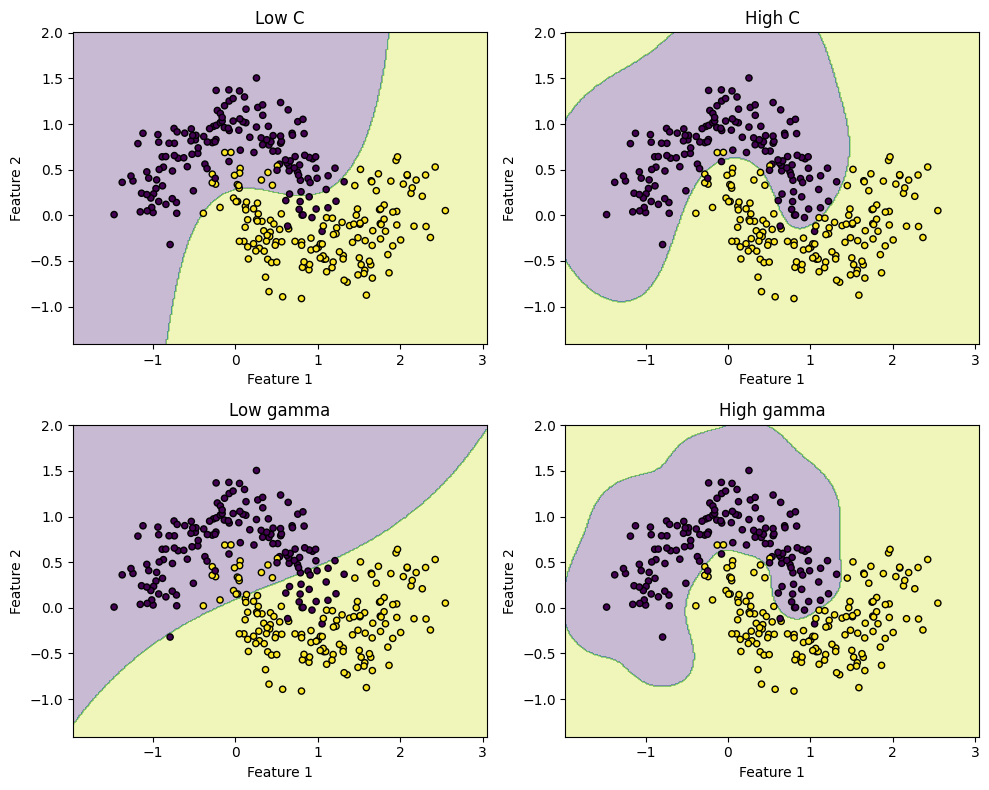

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

settings = [
    ('Low C', SVC(kernel='rbf', C=0.1, gamma='scale')),
    ('High C', SVC(kernel='rbf', C=100, gamma='scale')),
    ('Low gamma', SVC(kernel='rbf', C=1, gamma=0.1)),
    ('High gamma', SVC(kernel='rbf', C=1, gamma=10))
]

for ax, (title, model) in zip(axes.ravel(), settings):
    plot_decision_boundary(ax, model, X_moons, y_moons, title)

plt.tight_layout()
plt.savefig("RBF_Hyperparameters.png", dpi=300, bbox_inches='tight')
plt.show()

## Summarise the Main Results

This cell provides a short summary of the most important model results from the notebook.

In [15]:
best_params = grid_search.best_params_

print("Best tuned model: Linear SVM")
print("Best C value:", best_params['svc__C'])
print("Best kernel:", best_params['svc__kernel'])
print("Best CV accuracy:", round(grid_search.best_score_, 4))
print("Test accuracy:", round(test_accuracy, 4))

Best tuned model: Linear SVM
Best C value: 100
Best kernel: linear
Best CV accuracy: 0.9681
Test accuracy: 0.9057
